In [1]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt
from datetime import datetime


In [2]:
# pulizia per sicurezza

os.system("rm *.h5")
os.system("rm *.xml")
os.system("rm *.out")
os.system("rm *.png")

rm: cannot remove '*.h5': No such file or directory
rm: cannot remove '*.xml': No such file or directory
rm: cannot remove '*.out': No such file or directory
rm: cannot remove '*.png': No such file or directory


256

VARIABILI IMPORTANTI

In [3]:
# Cella con tag: parameters
param_file = '../parametri.txt'

In [4]:
# Parameters
param_file = "/mnt/c/Users/ASUS/Desktop/WSL_Shared/Tesi_magistrale/Open MC/reattore_4/parametri_1.txt"


In [5]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters(param_file)


# --- Parametri Geometrici ---
R_CORE    = p['R_CORE']
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']

# --- Parametri Logici ---
R_PIPE    = p['R_PIPE']

# --- Parametri Pin/Lattice ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']
PITCH     = p['PITCH']

# --- Parametri Target ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']

# --- Sorgente e Simulazione ---
S             = p['S']

bin_ris       = p['bin_ris']

batches       = p['batches_auto']
particles     = p['particles_auto']
inactive      = p['inactive_auto']

arricchimento = p['arricchimento']
mix = p['mix_acqua']
pressione_funzionamento = p['Pressione_funzionamento']


MATERIALI

In [6]:
fuel = openmc.Material(name='fuel')
fuel.add_nuclide('U235', arricchimento)
fuel.add_nuclide('U238', 1.0 - arricchimento)
fuel.add_nuclide('O16', 2.0)
fuel.set_density('g/cm3', 10.96)

# materiale di rivestimento
cladding = openmc.Material (name = 'cladding')
cladding.add_element('Zr', 1.0) 
cladding.set_density('g/cm3', 6.49)

# materiale di moderatore
water = openmc.Material (name = 'water')
water.add_nuclide('H1', mix)
water.add_nuclide('H2', 1-mix)
water.add_element('O', 1.0)
water.set_density('g/cm3', 1.10)
water.add_s_alpha_beta('c_D_in_D2O') # aggiungo la tabella di scattering termico
water.add_s_alpha_beta('c_H_in_H2O') # aggiungo la tabella di scattering termico
# n.b.  le sezioni d'urto veloci sono già incluse di default


# aggiungo un riflettore 
reflector = openmc.Material(name='reflector')
reflector.add_element('C',1.0)
reflector.set_density('g/cm3', 1.75) 

# voglio una sorgente puntiforme di neutroni in un punto specifico
marker_mat = openmc.Material(name='marker')
marker_mat.set_density('g/cm3', 1e-10) # Densità quasi nulla per non disturbare la fisica
marker_mat.add_nuclide('He4', 1.0) # elio, non interagisce praticamente

void_air = openmc.Material(name='void_air')
void_air.set_density('g/cm3', 1e-10) # Densità
void_air.add_nuclide('N14', 1 )

mat_target = openmc.Material(name='mat_target')
mat_target.add_nuclide('U235', arricchimento)
mat_target.add_nuclide('U238', 1.0 - arricchimento)
mat_target.add_nuclide('O16', 2.0)
mat_target.set_density('g/cm3', 10.96)

materials = openmc.Materials([fuel, cladding, water, reflector, marker_mat, void_air, mat_target])

materials.cross_sections = "/home/bossi_ricky/openmc_data/mcnp_endfb71/cross_sections.xml" # per fotonucleari

materials.export_to_xml()

GEOMETRIA

In [7]:
# --- 0. PIANI Z (ASSOLUTI) ---
z_bot_ref = openmc.ZPlane(z0=-REF_BOT, boundary_type='vacuum')
z_bot_core = openmc.ZPlane(z0=0.0)
z_top_core = openmc.ZPlane(z0=H_CORE)
z_top_world = openmc.ZPlane(z0=H_CORE + 5.0, boundary_type='vacuum')

# Piani Z Target
z_mid = H_CORE - P_TARGET
z_tgt_bot = openmc.ZPlane(z0=z_mid - (H_TARGET / 2.0))
z_tgt_top = openmc.ZPlane(z0=z_mid + (H_TARGET / 2.0))

# Superficie Sorgente
sphere_src = openmc.Sphere(x0=0, y0=0, z0=H_CORE + 2, r=0.5)

# --- 1. CALCOLO DIMENSIONI TAGLIO CENTRALE ---
# Calcoliamo quanto deve essere grande il buco esagonale centrale
# Rimuoviamo gli anelli che cadono dentro R_PIPE
n_rings_removed = int(np.ceil(R_PIPE / PITCH))
# Il lato del prisma che useremo per "bucare" il lattice:
EDGE_PIPE_LARGE = (n_rings_removed - 0.5) * PITCH
if EDGE_PIPE_LARGE == 0: EDGE_PIPE_LARGE = PITCH # Sicurezza minima

# --- 2. FORME GEOMETRICHE BASE ---

EDGE_FUEL = R_FUEL
EDGE_CLAD = R_FUEL + CLAD_THICK

# A. Prismi PIN
hex_fuel_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_FUEL, orientation='x')
hex_clad_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_CLAD, orientation='x')

# B. Prisma "TAGLIO" CENTRALE (Il buco grande nel reticolo)
hex_pipe_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_PIPE_LARGE, orientation='x')

# C. Cilindro Target (Unico centrale)
cyl_target = openmc.ZCylinder(r=R_TARGET)


# --- 3. UNIVERSI ---

# A. Universo PIN (Fuel -> Clad -> Water)
c_fuel = openmc.Cell(fill=fuel, region=hex_fuel_prism)
c_clad = openmc.Cell(fill=cladding, region=hex_clad_prism & ~hex_fuel_prism)
# Acqua definita "ovunque fuori dal cladding". Il confine sarà dato dal lattice.
c_water_pin = openmc.Cell(fill=water, region=~hex_clad_prism)

u_pin = openmc.Universe(cells=[c_fuel, c_clad, c_water_pin])


# C. Universo ACQUA ESTERNA (Riflettore/Gap)
c_water_full = openmc.Cell(fill=water)
u_water = openmc.Universe(cells=[c_water_full])


# --- 4. LATTICE (SOLO COMBUSTIBILE) ---
# Creiamo un lattice uniforme pieno SOLO di pin.
# Il buco centrale lo creiamo geometricamente nello step successivo, non qui.

num_rings = int(np.ceil(R_CORE / PITCH)) + 1
hex_core_edge = num_rings * PITCH
hex_ref_edge = hex_core_edge + REF_SIDE

lattice_universes = []
for i in range(num_rings):
    if i == 0:
        lattice_universes.append([u_pin])
    else:
        lattice_universes.append([u_pin] * (6 * i))

lattice = openmc.HexLattice(name='core_hex_lattice')
lattice.center = (0.0, 0.0)
lattice.pitch = (PITCH,)
lattice.outer = u_water
lattice.universes = lattice_universes[::-1] # Inversione fondamentale: Esterno -> Interno
lattice.orientation = 'x'

# --- 5. ASSEMBLAGGIO FINALE (GEOMETRIA DIRETTA) ---

prism_core = openmc.model.get_hexagonal_prism(edge_length=hex_core_edge, orientation='x')
prism_reflector = openmc.model.get_hexagonal_prism(edge_length=hex_ref_edge, orientation='x', boundary_type='vacuum')

# A. Cella Core (Lattice CON BUCO)
# ---------------------------------------------------------
# Prendiamo il prisma grande del core, e sottraiamo (~) il prisma del canale centrale.
# In questo modo il lattice viene "tagliato" via dal centro.
region_core = prism_core & ~hex_pipe_prism & +z_bot_core & -z_top_core
c_main_core = openmc.Cell(fill=lattice, region=region_core)


# B. Canale Centrale (Target + Vuoto) - DEFINIZIONE DIRETTA
# ---------------------------------------------------------
# 1. Definiamo il volume TOTALE del canale esagonale (da 0 a H_CORE)
region_central_hex_total = hex_pipe_prism & +z_bot_core & -z_top_core

# 2. Definiamo la regione del TARGET SOLIDO (Cilindro limitato in Z)
# Nota: Intersechiamo con region_central_hex_total per sicurezza, ma basterebbe il cilindro.
region_target_solid = region_central_hex_total & -cyl_target & +z_tgt_bot & -z_tgt_top

# 3. Definiamo la regione del VUOTO (Tutto il canale MENO il target)
# Usiamo l'operatore ~ (NOT) sulla regione del target.
region_void_gap = region_central_hex_total & ~region_target_solid

# Creazione delle celle
c_target = openmc.Cell(fill=mat_target, region=region_target_solid)
c_void_gap = openmc.Cell(fill=void_air, region=region_void_gap) 

# C. Riflettori (Rimangono uguali)
region_ref_side = prism_reflector & ~prism_core & +z_bot_core & -z_top_core
c_ref_side = openmc.Cell(fill=reflector, region=region_ref_side)

region_ref_bot = prism_reflector & +z_bot_ref & -z_bot_core
c_ref_bot = openmc.Cell(fill=reflector, region=region_ref_bot)

# D. Top World & Source (Rimangono uguali)
c_source_marker = openmc.Cell(fill=marker_mat, region=-sphere_src)
region_top = prism_reflector & +z_top_core & -z_top_world & +sphere_src
c_top_void = openmc.Cell(fill=void_air, region=region_top)

all_cells = [c_main_core, c_target, c_void_gap, c_ref_side, c_ref_bot, c_source_marker, c_top_void]
geometry = openmc.Geometry(all_cells)
geometry.export_to_xml()
print("Geometria generata correttamente.")

def count_fuel_pins(num_rings, pitch, r_pipe, r_core):
    total_pins = 0
    # Ring 0 è il centro
    for i in range(num_rings):
        ring_radius = i * pitch
        # Se l'anello è fuori dalla pipe centrale e dentro il raggio del core
        if ring_radius >= r_pipe and ring_radius <= r_core:
            if i == 0:
                total_pins += 1
            else:
                total_pins += (6 * i)
    return total_pins

n_barre = count_fuel_pins(num_rings, PITCH, R_PIPE, R_CORE)
print(f"Numero di barre di combustibile effettive: {n_barre} \n\n")

Geometria generata correttamente.
Numero di barre di combustibile effettive: 396 




/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:130: FutureWarning: get_hexagonal_prism(...) has been renamed hexagonal_prism(...). Future versions of OpenMC will not accept get_hexagonal_prism.
  warn("get_hexagonal_prism(...) has been renamed hexagonal_prism(...). "
/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:121: FutureWarning: The hexagonal_prism(...) function has been replaced by the HexagonalPrism(...) class. Future versions of OpenMC will not accept hexagonal_prism.
  warn("The hexagonal_prism(...) function has been replaced by the "


PLOTTING


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/plots.py:1307: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(



VISUALIZZAZIONE GEOMETRIA

1. VISTA DALL'ALTO (Piano XY nel Core)


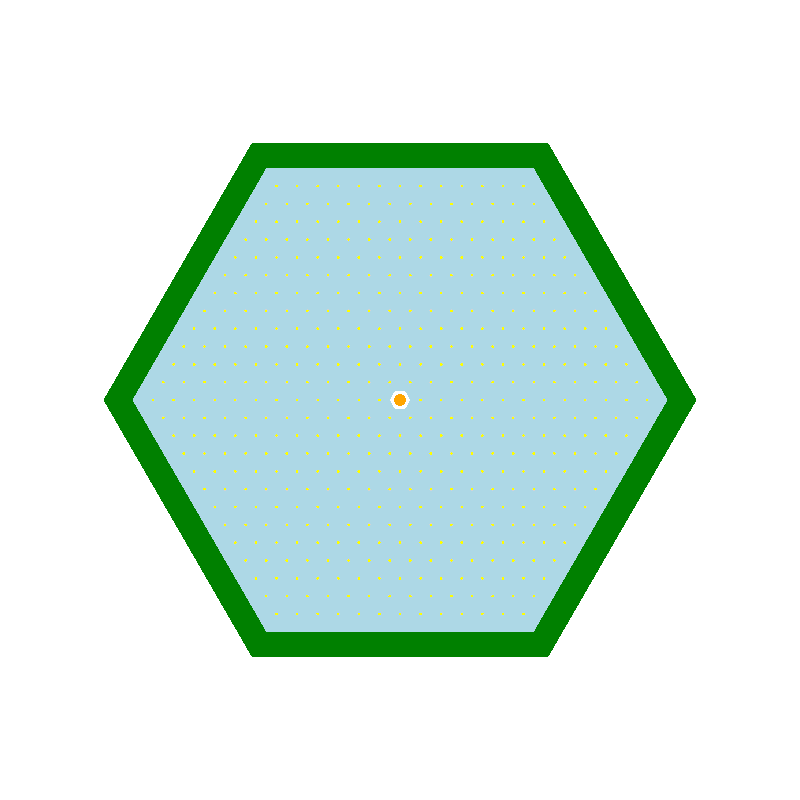

2. VISTA LATERALE (Piano XZ)


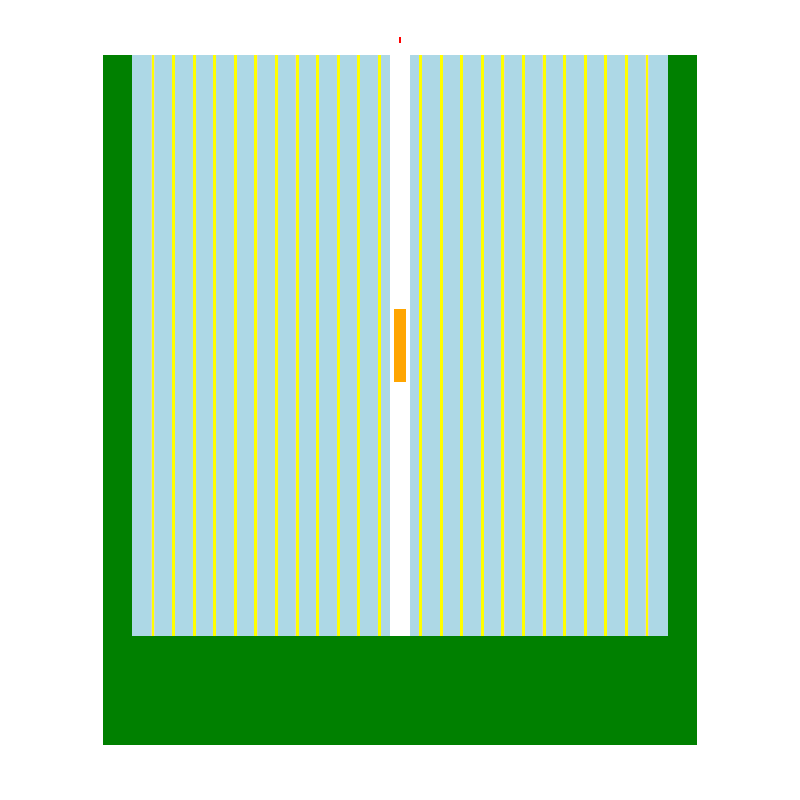


--- LEGENDA COLORI ---
■ yellow          : fuel
■ lightgray       : cladding
■ lightblue       : water
■ green           : reflector
■ red             : marker
■ white           : void_air
■ orange          : mat_target


In [8]:
color_map = {
    fuel: 'yellow',         # Combustibile
    cladding: 'lightgray',  # Cladding
    water: 'lightblue',     # Moderatore (acqua)
    reflector: 'green',     # Riflettore
    marker_mat: 'red' ,     # Marker sorgente
    void_air: 'white',      # Vuoto (aria)
    mat_target: 'orange'   # Target
}

# A. Vista dall'alto (Sezione nel mezzo del core)
p1 = openmc.Plot()
p1.basis = 'xy'
p1.origin = (0.0, 0.0, H_CORE / 2.0)
p1.width = (3 * (R_CORE + REF_SIDE + 2.0), 3 * (R_CORE + REF_SIDE + 2.0))
p1.pixels = (800, 800)
p1.color_by = 'material'
p1.colors = color_map
p1.filename = 'reactor_xy'

# B. Vista laterale (Sezione verticale XZ)
p2 = openmc.Plot()
p2.basis = 'xz'
p2.origin = (0.0, 0.0, (H_CORE - REF_BOT) / 2.0) 
p2.width = (3 * (R_CORE + REF_SIDE + 2.0), H_CORE + REF_BOT + 15.0)
p2.pixels = (800, 800)
p2.color_by = 'material'
p2.colors = color_map
p2.filename = 'reactor_xz'

# Esporto tutti i plot nel file XML
plots = openmc.Plots([p1, p2])
plots.export_to_xml()

# Eseguo il plotter: ho rimosso open_browser=False che causava l'errore
# OpenMC genererà i file .png basandosi sui nomi definiti (reactor_xy.png, ecc.)
openmc.plot_geometry() 

print("\n" + "="*30)
print("VISUALIZZAZIONE GEOMETRIA")
print("="*30 + "\n")

print("1. VISTA DALL'ALTO (Piano XY nel Core)")
display(Image('reactor_xy.png'))

print("2. VISTA LATERALE (Piano XZ)")
display(Image('reactor_xz.png'))

# Legenda finale
print("\n--- LEGENDA COLORI ---")
for mat, col in color_map.items():
    print(f"■ {col.ljust(15)} : {mat.name}")

SETTING EIGENVALUED

In [9]:
settings_k = openmc.Settings()
settings_k.run_mode = 'eigenvalue'
settings_k.batches = batches
settings_k.particles = particles
settings_k.inactive = inactive

# Definiamo un box che racchiude l'intero core
lower_left = [-R_CORE, -R_CORE, 0.0]
upper_right = [R_CORE, R_CORE, H_CORE]

# Creazione di una distribuzione spaziale uniforme confinata ai materiali fessili
uniform_dist = openmc.stats.Box(lower_left, upper_right, only_fissionable=True)

settings_k.source = openmc.IndependentSource(space=uniform_dist)

# Override della frazione di rigetto
settings_k.source_rejection_fraction = 0.001 
settings_k.temperature = {'method': 'interpolation'}

# Esportazione
settings_k.export_to_xml()


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


In [10]:
tallies = openmc.Tallies()

filter_termico = openmc.EnergyFilter([0.0, 0.625])
filter_veloce = openmc.EnergyFilter([0.625, 20.0e6])
fuel_filter = openmc.MaterialFilter(fuel)
neutron_filter = openmc.ParticleFilter(['neutron'])
photon_filter = openmc.ParticleFilter(['photon'])


#FORMULA DEI 4 FATTORI ( sono parametri integrali, non posso usare quelli precedentemente calcoalti)

# 1. Fissione Totale
fission_tot = openmc.Tally(name='fission_tot')
fission_tot.filters = [neutron_filter]
fission_tot.scores = ['nu-fission', 'fission']
tallies.append(fission_tot)

# 2. Fissione Termica
fission_th = openmc.Tally(name='fission_th')
fission_th.filters = [filter_termico, neutron_filter]
fission_th.scores = ['nu-fission']
tallies.append(fission_th)

# 3. Assorbimento Totale
abs_tot = openmc.Tally(name='abs_tot')
abs_tot.filters = [neutron_filter]
abs_tot.scores = ['absorption']
tallies.append(abs_tot)

# 4. Assorbimento Termico
abs_th = openmc.Tally(name='abs_th')
abs_th.filters = [filter_termico, neutron_filter]
abs_th.scores = ['absorption']
tallies.append(abs_th)

# 5. Assorbimento Termico nel Combustibile
abs_th_fuel = openmc.Tally(name='abs_th_fuel')
abs_th_fuel.filters = [filter_termico, fuel_filter, neutron_filter]
abs_th_fuel.scores = ['absorption']
tallies.append(abs_th_fuel)

tallies.export_to_xml()

In [11]:
from CoolProp.CoolProp import PropsSI

def densita_mix_dinamica(T_K, P_Pa=pressione_funzionamento, frac_mass_H2O=mix):
    # Calcolo in kg/m^3 e conversione in g/cm^3
    rho_H2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'Water') / 1000     # D sta per densità
    rho_D2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'HeavyWater') / 1000
    
    # Calcolo miscela assumendo volumi ideali additivi
    rho_mix = 1 / (frac_mass_H2O / rho_H2O + (1 - frac_mass_H2O) / rho_D2O) # Formula di additività dei volumi specifici
    return rho_mix

In [12]:
# FORMULA DEI 4 FATTORI DA SLIDE PROF

def calculate_four_factor_formula(statepoint_file):

    sp = openmc.StatePoint(statepoint_file)

    # epsilon è il fast fission factor, cioè quanta probabilità di fissione ho per un neutrone veloce

    # --- ESTRAZIONE DATI ---
    # Utilizziamo .flatten()[0] per estrarre direttamente il valore scalare
    val_fiss_tot = sp.get_tally(name='fission_tot').get_values(scores=['nu-fission'], value='mean').flatten()[0]
    val_fiss_th  = sp.get_tally(name='fission_th').get_values(scores=['nu-fission'], value='mean').flatten()[0]

    val_abs_tot  = sp.get_tally(name='abs_tot').get_values(scores=['absorption'], value='mean').flatten()[0]
    val_abs_th   = sp.get_tally(name='abs_th').get_values(scores=['absorption'], value='mean').flatten()[0]

    val_abs_th_fuel = sp.get_tally(name='abs_th_fuel').get_values(scores=['absorption'], value='mean').flatten()[0]


    # --- CALCOLO DEI 4 FATTORI ---
    epsilon = val_fiss_tot / val_fiss_th
    p       = val_abs_th / val_abs_tot
    f       = val_abs_th_fuel / val_abs_th
    eta     = val_fiss_th / val_abs_th_fuel

    # Calcolo k_infine analitico
    k_inf_analytical = epsilon * p * f * eta
    #Estrazione della Leakage fraction da statepoint
    gt = sp.global_tallies
    nomi = [n.decode() if isinstance(n, bytes) else n for n in gt['name']]
    idx = nomi.index('leakage')
    media = gt['mean'][idx]
    dev_std = gt['std_dev'][idx]

    Leakage_Fraction = media

    # --- STAMPA RISULTATI ---
    print("\n=== FORMULA DEI 4 FATTORI ===")
    print(f"Epsilon (Fast Fission)        : {epsilon:.5f}")
    print(f"p       (Resonance Escape)    : {p:.5f}")
    print(f"f       (Thermal Utilization) : {f:.5f}")
    print(f"Eta     (Reproduction)        : {eta:.5f}")
    print("Leakage_Fraction              : {:.5f}".format(Leakage_Fraction))
    print("-" * 30)
    print(f"k_inf (Analitico 4-factors)   : {k_inf_analytical:.5f}")

    k_inf_leakage = k_inf_analytical *  (1-Leakage_Fraction)
    print(f"k_inf con Leakage (4-factors)  : {k_inf_leakage:.5f}")
    print("-" * 30)
    print ("\n\n")
 

    return epsilon, p, f, eta, Leakage_Fraction, k_inf_leakage 

In [13]:
now = datetime.now()
timestamp = now.strftime("\n\n------ SIMULAZIONE DEL %d/%m/%Y ALLE ORE %H:%M ------\n")
output_file = "result.txt"

# Inizializzazione Header
with open(output_file, "a") as f_out:
    f_out.write(timestamp)
    f_out.write("=== PARAMETRI DI SIMULAZIONE ===\n")

    f_out.write(f"intensità sorgente: {S} fotoni/s\n")

    f_out.write(f"Arricchimento: {arricchimento}\n")
    f_out.write(f"Pressione di funzionamento: {pressione_funzionamento} Pa\n")
    f_out.write(f"percentuale di acqua leggera nella miscela: {mix*100:.2f} % \n")

    f_out.write(f"RAGGGIO CORE: {R_CORE} cm\n")
    f_out.write(f"REFLECTOR SIDE: {REF_SIDE} cm\n")
    f_out.write(f"REFLECTOR BOTTOM: {REF_BOT} cm\n")
    f_out.write(f"H_CORE: {H_CORE} cm\n")

    f_out.write(f"R_PIPE (Soglia): {R_PIPE} cm\n")
    f_out.write(f"Geometria PIN (R_FUEL, CLAD, R_WATER): {R_FUEL}, {CLAD_THICK}, {R_WATER_THICK} cm\n")
    f_out.write(f"PITCH: {PITCH:.5f} cm\n")

    f_out.write(f"Target (R, H, Pos): {R_TARGET}, {H_TARGET}, {P_TARGET} cm\n")
    f_out.write(f"Settings: {batches} batches, {particles} particles, {inactive} inactive batches\n")
    
    f_out.write("================================\n\n")

    f_out.write(f"{'T_WATER [K]':<12} {'T_FUEL [K]':<12} {'K_EFF':<12} {'STD_DEV':<12} {'EPSILON':<12} {'P':<12} {'F':<12} {'ETA':<12} {'LEAKAGE_FRACTION':<12} {'K_INF_LEAKAGE':<12}\n") # Intestazione Colonne
 

T_water_vals = list(range(300, 351, 5))

map_densita = dict(zip(T_water_vals, [densita_mix_dinamica(T) for T in T_water_vals]))

for T_water in T_water_vals:

    water.temperature = T_water
    water.set_density('g/cm3', map_densita[T_water])
   
    for T in range(300, 701, 25):
        print(f"Simulazione: H2O={T_water}K, Fuel={T}K")
        fuel.temperature = T
        cladding.temperature = T
        reflector.temperature = T
        mat_target.temperature = T

        # Export XML (Fondamentale dentro i loop se cambiano i valori)
        mats = openmc.Materials([fuel, cladding, water, reflector, marker_mat, void_air, mat_target])
        mats.cross_sections = "/home/bossi_ricky/openmc_data/mcnp_endfb71/cross_sections.xml"
        mats.export_to_xml()
        
        percorso_eseguibile = "/home/bossi_ricky/miniconda3/envs/openmc-env/bin/openmc"
        openmc.run(openmc_exec=percorso_eseguibile, output=False)
        sp_filename = f'statepoint.{batches}.h5'

        if os.path.exists(sp_filename):
            with openmc.StatePoint(sp_filename) as sp:
                k_val = sp.k_combined.nominal_value
                k_std = sp.k_combined.std_dev

                print(f"valore di k: {k_val:.5f} +/- {k_std:.5f}")

                epsilon, p, f, eta, Leakage_Fraction, k_inf_leakage = calculate_four_factor_formula(sp_filename)
                

                with open(output_file, "a") as f_out:
                    # Inserisco anche T_water per chiarezza nel file
                    f_out.write(f"{T_water:<12} {T:<12} {k_val:<12.5f} {k_std:<12.5f} {epsilon:<12.5f} {p:<12.5f} {f:<12.5f} {eta:<12.5f} {Leakage_Fraction:<12.5f} {k_inf_leakage:<12.5f}\n")

            os.remove(sp_filename)

        if os.path.exists('summary.h5'):
            os.remove('summary.h5')

Simulazione: H2O=300K, Fuel=300K


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


valore di k: 1.05759 +/- 0.00035



=== FORMULA DEI 4 FATTORI ===
Epsilon (Fast Fission)        : 1.05739
p       (Resonance Escape)    : 0.90067
f       (Thermal Utilization) : 0.80537
Eta     (Reproduction)        : 1.93945
Leakage_Fraction              : 0.29159
------------------------------
k_inf (Analitico 4-factors)   : 1.48758
k_inf con Leakage (4-factors)  : 1.05382
------------------------------



Simulazione: H2O=300K, Fuel=325K


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


...

/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


valore di k: 1.05352 +/- 0.00036

=== FORMULA DEI 4 FATTORI ===
Epsilon (Fast Fission)        : 1.05798
p       (Resonance Escape)    : 0.89737
f       (Thermal Utilization) : 0.80815
Eta     (Reproduction)        : 1.93882
Leakage_Fraction              : 0.29459
------------------------------
k_inf (Analitico 4-factors)   : 1.48759
k_inf con Leakage (4-factors)  : 1.04936
------------------------------



Simulazione: H2O=320K, Fuel=675K


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


valore di k: 1.05291 +/- 0.00030

=== FORMULA DEI 4 FATTORI ===
Epsilon (Fast Fission)        : 1.05790
p       (Resonance Escape)    : 0.89715
f       (Thermal Utilization) : 0.80825
Eta     (Reproduction)        : 1.93861
Leakage_Fraction              : 0.29458
------------------------------
k_inf (Analitico 4-factors)   : 1.48713
k_inf con Leakage (4-factors)  : 1.04905
------------------------------



Simulazione: H2O=320K, Fuel=700K


KeyboardInterrupt: 